In this notebook, we do some testing in our DualEncoderFNO trained model.

### 1. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from neuralop import LpLoss, H1Loss

from rve_analyzer import RVEDataset, DualEncoderFNO, RVEInferencer, RVEVisualizer

### 2. Configuration

In [2]:
from types import SimpleNamespace

cfg = SimpleNamespace(**{})

In [3]:
cfg.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {cfg.device}")

Device: cuda


In [4]:
cfg.h5_path = Path("../master_data/rve_run2.h5")
cfg.batch_size = 64
cfg.num_workers = 0
cfg.seed = 42
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

### 3. Datasets & DataLoader

In [5]:
cfg.in_memory = True
cfg.fraction = 1.00

test_dataset  = RVEDataset(cfg.h5_path, split='test', in_memory=cfg.in_memory, fraction=cfg.fraction)

Loading 100% of 'test' split into RAM. This may take a moment...
=== DEBUG SHAPES ===
x_local shape          : torch.Size([20000, 1, 96, 96])
x_global shape         : torch.Size([20000, 3])
y_local shape          : torch.Size([20000, 3, 96, 96])
--- Normalizer Shapes ---
x_normalizer.mean shape: torch.Size([1, 1, 1])
x_normalizer.std shape : torch.Size([1, 1, 1])
global_normalizer.mean shape: torch.Size([3])
global_normalizer.std shape : torch.Size([3])
y_normalizer.mean shape: torch.Size([3, 1, 1])
y_normalizer.std shape : torch.Size([3, 1, 1])


In [6]:
persistent_workers = True if cfg.num_workers > 0 else False
prefetch_factor = 4 if cfg.num_workers > 0 else None

test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True, 
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

### 4. Model loading

In [7]:
def load_trained_model(checkpoint_dir: str = "../checkpoints", model_name_prefix: str = "rve_fno"):
    
    path = Path(checkpoint_dir)
    
    # Load and instance model
    config = torch.load(path / f"{model_name_prefix}_config.pth", weights_only=False)
    model = DualEncoderFNO(**config)
    
    # Load Weights and Bias
    checkpoint = torch.load(path / f"{model_name_prefix}_params.pth")
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Load normalizers
    normalizers = torch.load(path / f"{model_name_prefix}_normalizers.pth", weights_only=False)
    
    return model, normalizers

In [8]:
model, normalizers = load_trained_model(model_name_prefix="rve2_fno_v8")
model.to(cfg.device)
print("Model and normalizers loaded.")

Model and normalizers loaded.


In [9]:
def check_normalization_per_channel(dataset, in_channels, n_macro, out_channels, batch_size=32):
    """
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Initialize zero tensors to accumulate sum and squared sum per channel
    xl_sum = torch.zeros(in_channels)
    xl_sq_sum = torch.zeros(in_channels)
    xl_count = 0
    
    xg_sum = torch.zeros(n_macro)
    xg_sq_sum = torch.zeros(n_macro)
    xg_count = 0
    
    y_sum = torch.zeros(out_channels)
    y_sq_sum = torch.zeros(out_channels)
    y_count = 0

    print("Computing mean and standard deviation per channel...")

    for xl, xg, y in loader:
        B = xl.size(0)  # Current batch size
        
        # Process x_local: [B, C_in, H, W] -> Flatten spatial dims to [B, C_in, N]
        xl_flat = xl.view(B, in_channels, -1)
        # Sum along the batch dimension (0) and spatial pixels (2), preserving channels (1)
        xl_sum += xl_flat.sum(dim=(0, 2))
        xl_sq_sum += (xl_flat ** 2).sum(dim=(0, 2))
        # Total elements per channel: Batch size * Number of pixels
        xl_count += B * xl_flat.size(2)
        
        # Process x_global: Assuming shape [B, n_macro] (no spatial dimensions)
        xg_sum += xg.sum(dim=0)
        xg_sq_sum += (xg ** 2).sum(dim=0)
        xg_count += B
        
        # Process y_local: [B, C_out, H, W] -> Flatten to [B, C_out, N]
        y_flat = y.view(B, out_channels, -1)
        y_sum += y_flat.sum(dim=(0, 2))
        y_sq_sum += (y_flat ** 2).sum(dim=(0, 2))
        y_count += B * y_flat.size(2)

    # Helper function to compute the final mean and std per channel
    def get_channel_stats(c_sum, c_sq_sum, count):
        mean = c_sum / count
        # Variance = E[X^2] - (E[X])^2
        variance = (c_sq_sum / count) - (mean ** 2)
        # Clamp to 0 to avoid negative variances due to floating-point precision errors
        variance = torch.clamp(variance, min=0.0)
        std = torch.sqrt(variance)
        return mean, std

    # Compute final statistics
    xl_mean, xl_std = get_channel_stats(xl_sum, xl_sq_sum, xl_count)
    xg_mean, xg_std = get_channel_stats(xg_sum, xg_sq_sum, xg_count)
    y_mean, y_std = get_channel_stats(y_sum, y_sq_sum, y_count)

    # Print the final report
    print("\n" + "="*50)
    print("NORMALIZATION REPORT")
    print("="*50)

    def print_stats(name, mean_tensor, std_tensor, tol=0.05):
        print(f"\n--- {name} ---")
        for i, (m, s) in enumerate(zip(mean_tensor, std_tensor)):
            # Visual warning if a channel deviates from Mean=0 and Std=1
            status = "✅" if (abs(m.item()) < tol and abs(s.item() - 1.0) < tol) else "⚠️"
            print(f"Channel {i}: Mean = {m.item():7.4f} | Std = {s.item():7.4f}  {status}")

    print_stats("x_local (in_channels)", xl_mean, xl_std)
    print_stats("x_global (n_macro)", xg_mean, xg_std)
    print_stats("y_local (out_channels)", y_mean, y_std)
    print("\n" + "="*50)

# Execute the check on the training dataset
check_normalization_per_channel(test_dataset, 1, 3, 3, batch_size=cfg.batch_size )

Computing mean and standard deviation per channel...

NORMALIZATION REPORT

--- x_local (in_channels) ---
Channel 0: Mean = -0.0000 | Std =  1.0000  ✅

--- x_global (n_macro) ---
Channel 0: Mean = -0.0148 | Std =  1.0232  ✅
Channel 1: Mean = -0.0947 | Std =  1.0229  ⚠️
Channel 2: Mean =  0.0339 | Std =  0.9832  ✅

--- y_local (out_channels) ---
Channel 0: Mean = -0.0456 | Std =  0.9954  ✅
Channel 1: Mean = -0.0603 | Std =  0.9992  ⚠️
Channel 2: Mean =  0.0123 | Std =  0.9997  ✅



### 5. Model evaluation

In [10]:
l2loss = LpLoss(d=2, p=2, reduction='mean')     # L2 loss for function values
h1loss = H1Loss(d=2, reduction='mean')

In [11]:
@torch.inference_mode()
def evaluate_model(model, dataloader, device, l2_loss, h1_loss):
    model.eval()
    total_l2 = 0.0
    total_h1 = 0.0
    total_samples = 0
    
    for batch in tqdm(dataloader, desc="Evaluating Test Set"):
        x_local, x_global, y_local = batch
        x_local = x_local.to(device)
        x_global = x_global.to(device)
        y_local = y_local.to(device)
        
        pred = model(x_local, x_global)
        
        batch_l2 = l2_loss(pred, y_local).item()
        batch_h1 = h1_loss(pred, y_local).item()
        batch_size = x_local.size(0)
        
        total_l2 += batch_l2 * batch_size
        total_h1 += batch_h1 * batch_size
        total_samples += batch_size
    
    avg_l2 = total_l2 / total_samples
    avg_h1 = total_h1 / total_samples
    return avg_l2, avg_h1

test_l2, test_h1 = evaluate_model(model, test_loader, cfg.device, l2loss, h1loss)
print(f"Test L2 Loss: {test_l2:.6f}")
print(f"Test H1 Loss: {test_h1:.6f}")

Evaluating Test Set: 100%|██████████| 313/313 [00:48<00:00,  6.46it/s]

Test L2 Loss: 0.136789
Test H1 Loss: 0.125863


In [12]:
# Create inferencer (assuming normalizers is a dict with 'y_local')
inferencer = RVEInferencer(model, normalizers['y_normalizer'], device=cfg.device)

In [13]:
# Get predictions for the entire test set
y_true, y_pred = inferencer.predict_dataset(test_loader)
print(f"Ground Truth shape: {y_true.shape}")
print(f"Predictions shape: {y_pred.shape}")

Ground Truth shape: (20000, 96, 96, 3)
Predictions shape: (20000, 96, 96, 3)


In [14]:
phase_array = np.array([test_dataset[i][0].numpy() for i in range(len(test_dataset))])

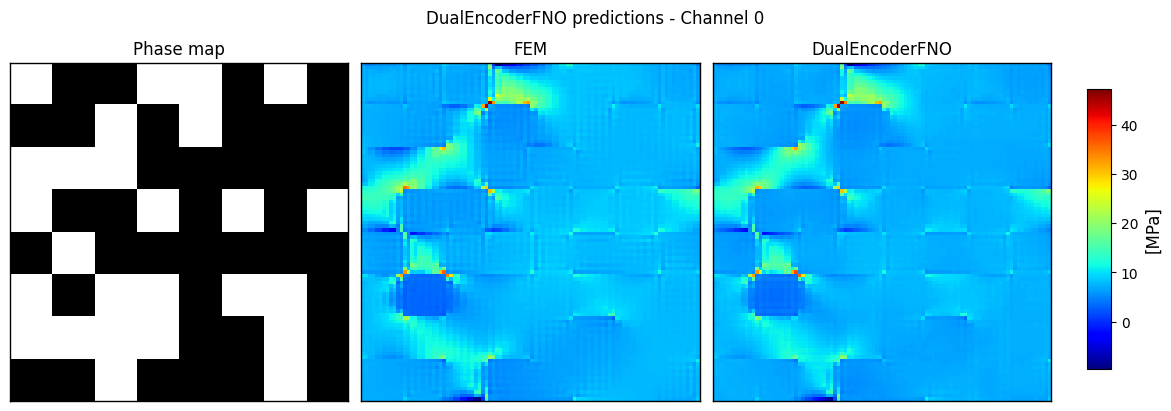

In [15]:
# Visualize contours for a sample
RVEVisualizer.plot_contours(
    phase=phase_array,  # Phase map
    y_true=y_true,      # Ground truth
    y_pred=y_pred,      # Prediction
    index=0,           # Case to visualize
    channel=0,          # Channel to visualize
    cmap='jet'          # 
)

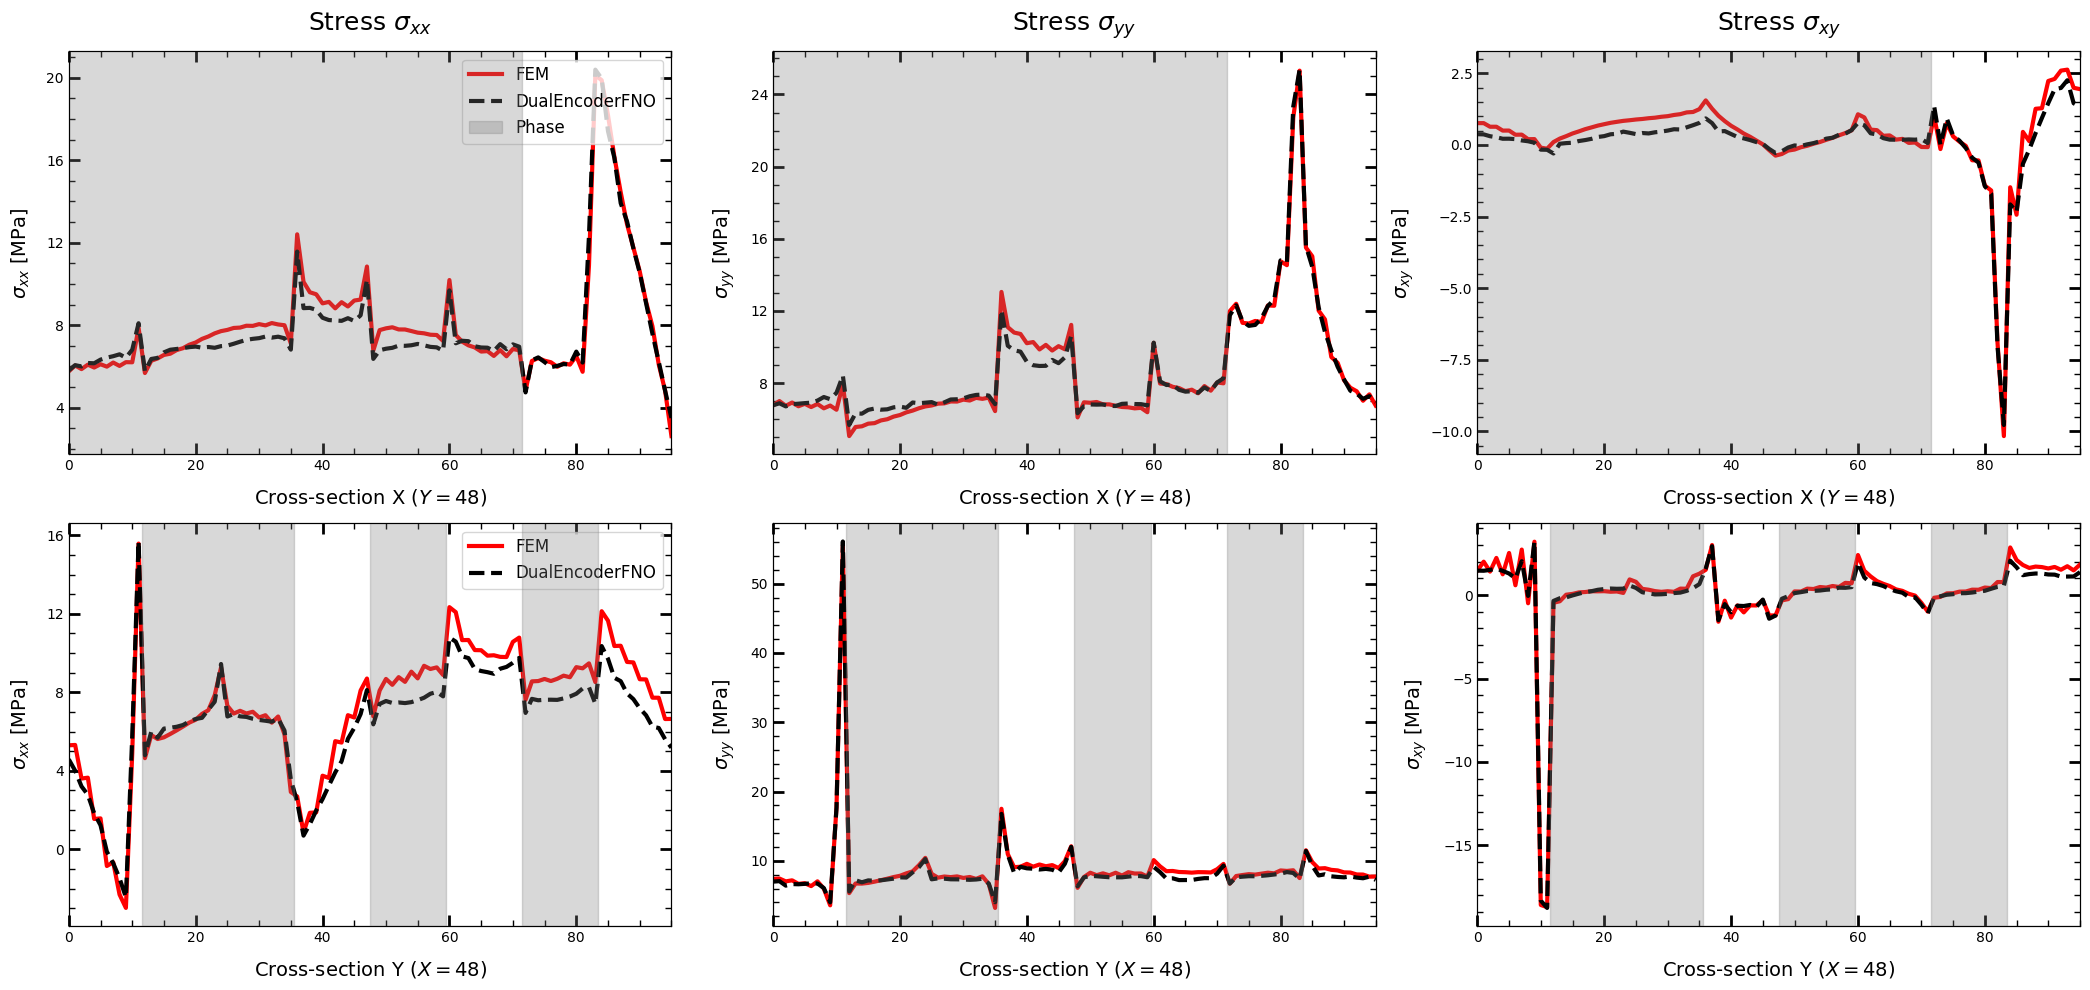

In [16]:
# Visualize cross-sections for the same sample
RVEVisualizer.plot_cross_sections(phase_array, y_true, y_pred, index=0, variable='Stress')  # Adjust hline/vline if needed

Sample 483:


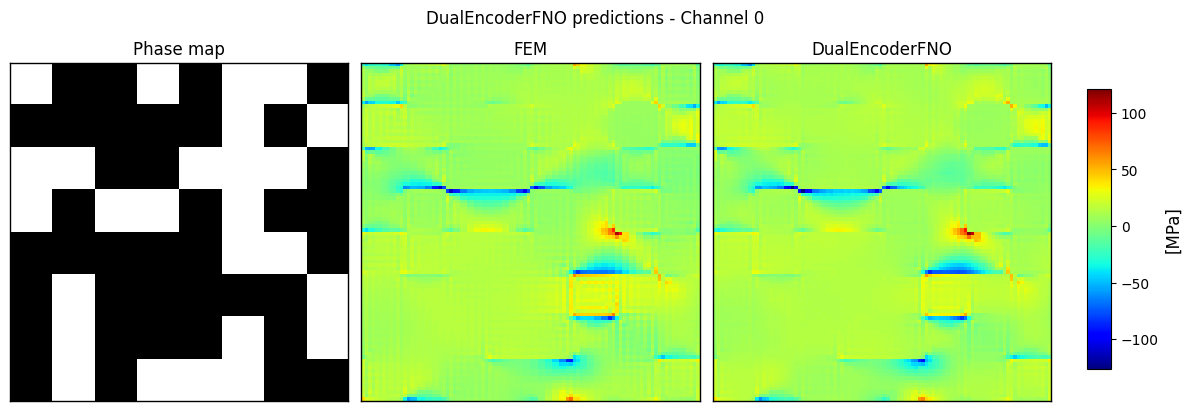

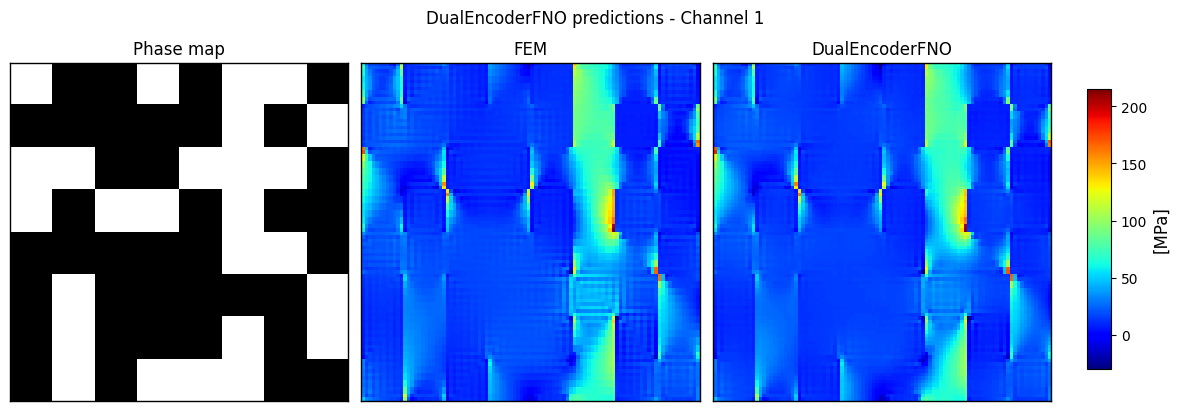

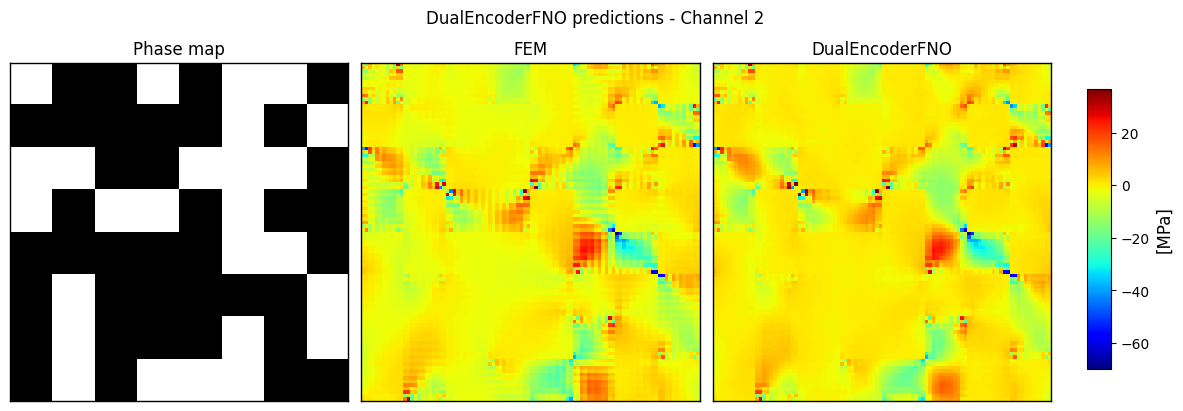

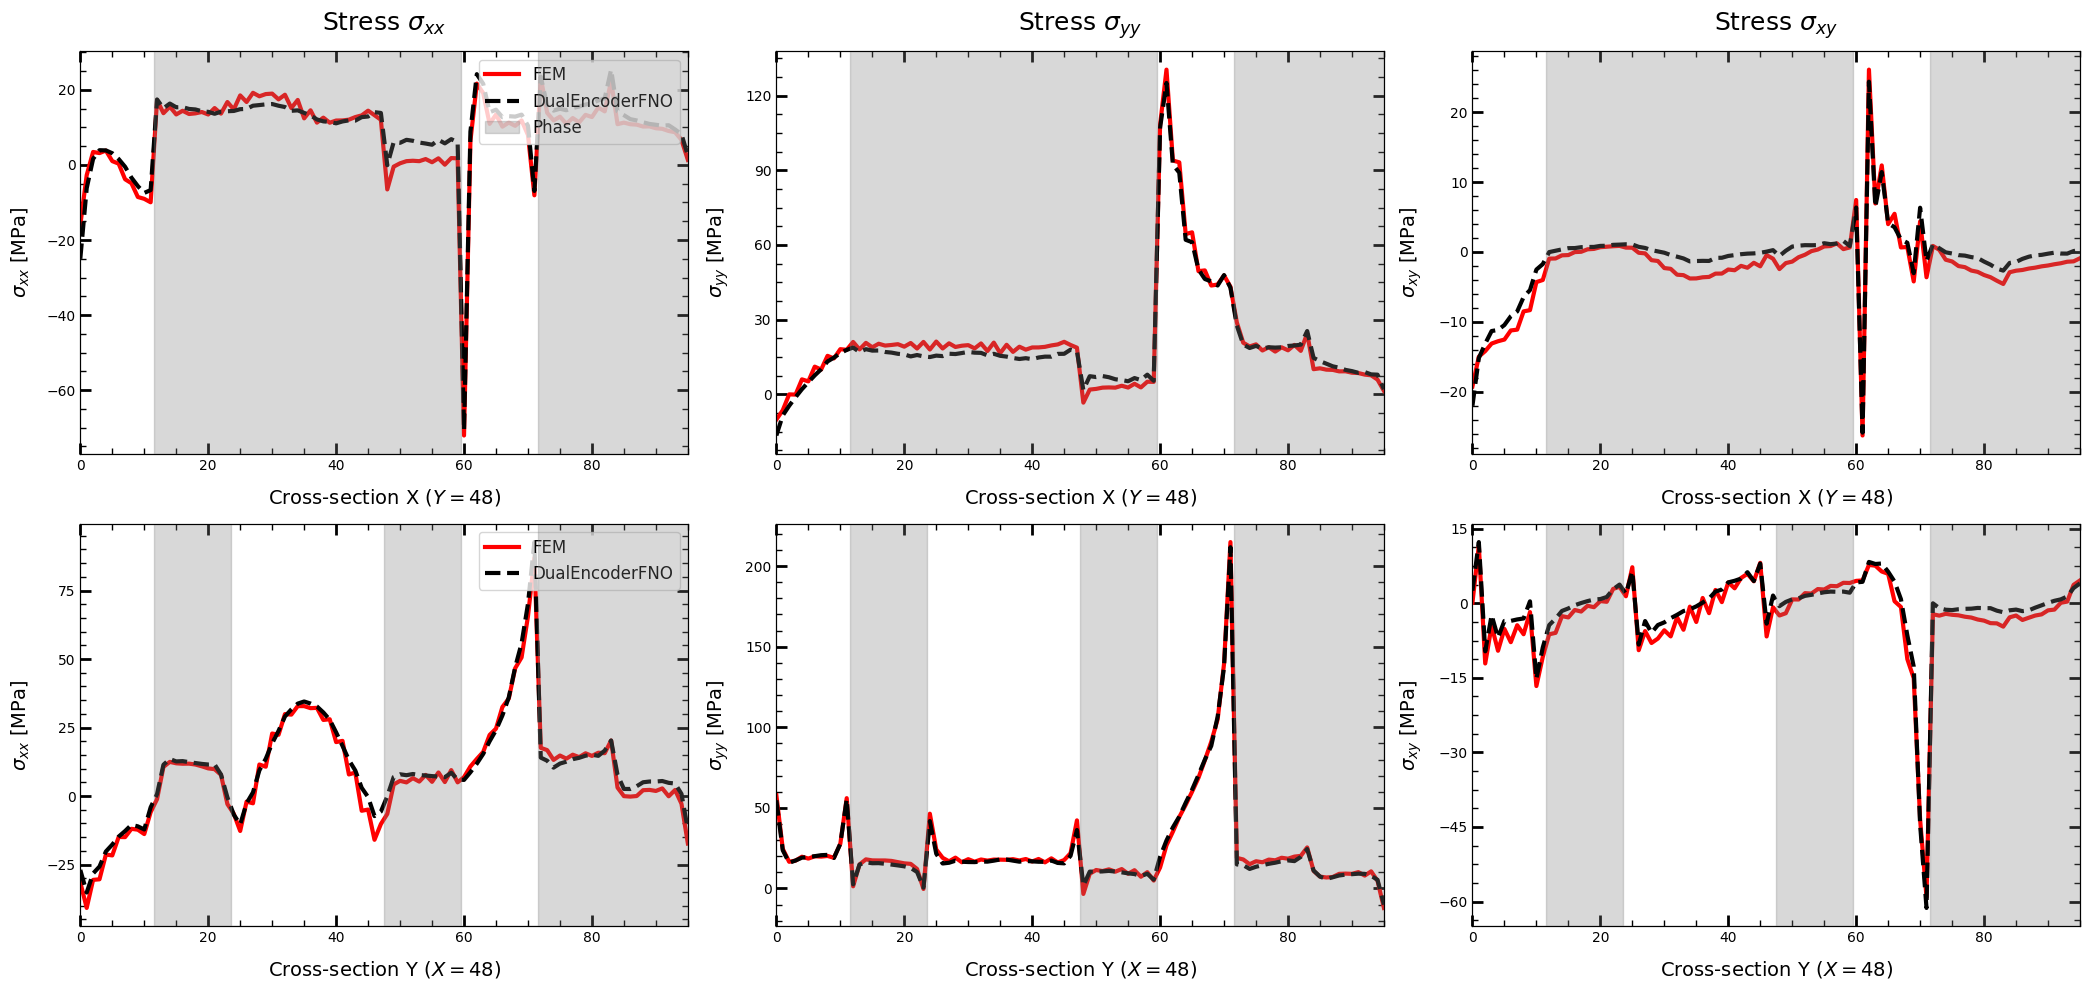

Sample 13829:


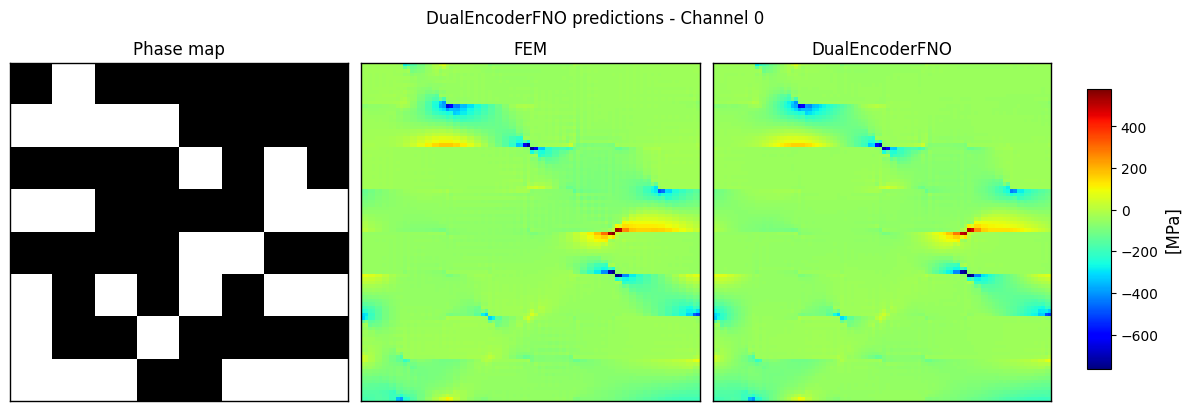

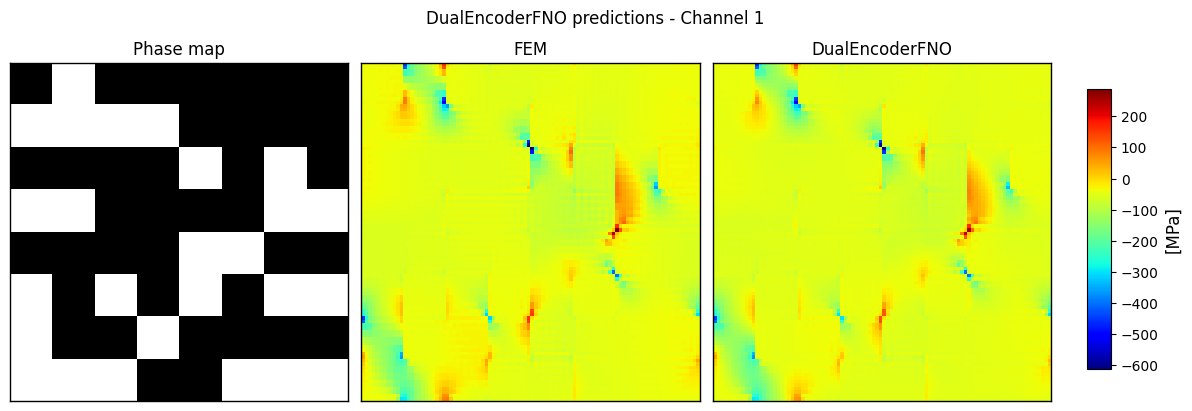

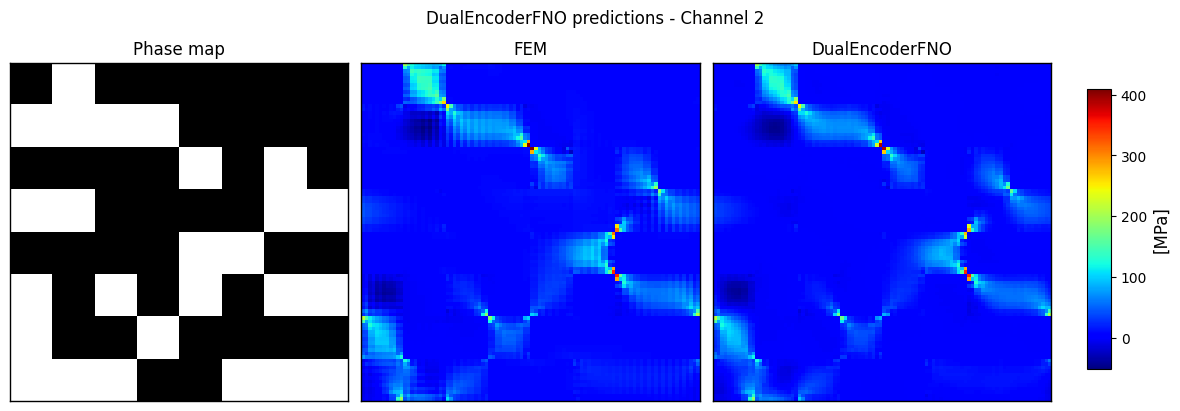

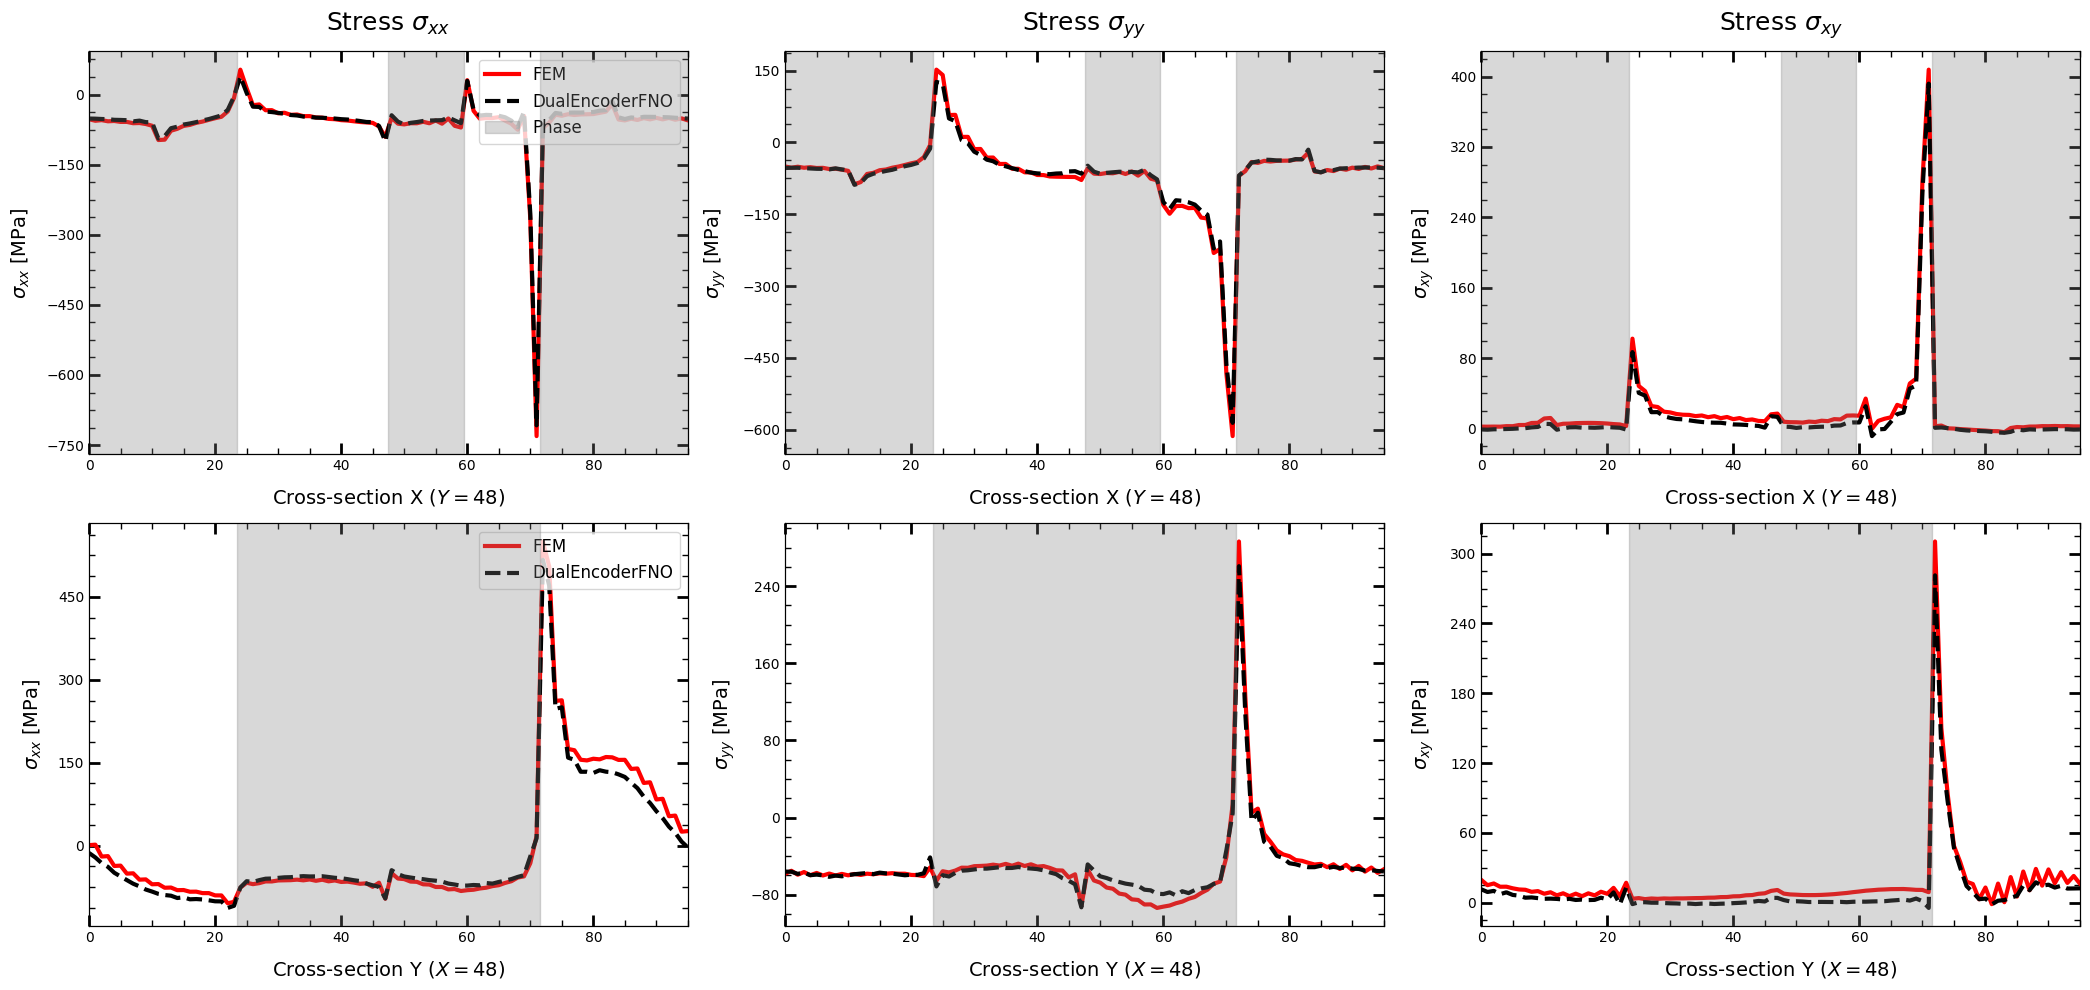

Sample 16253:


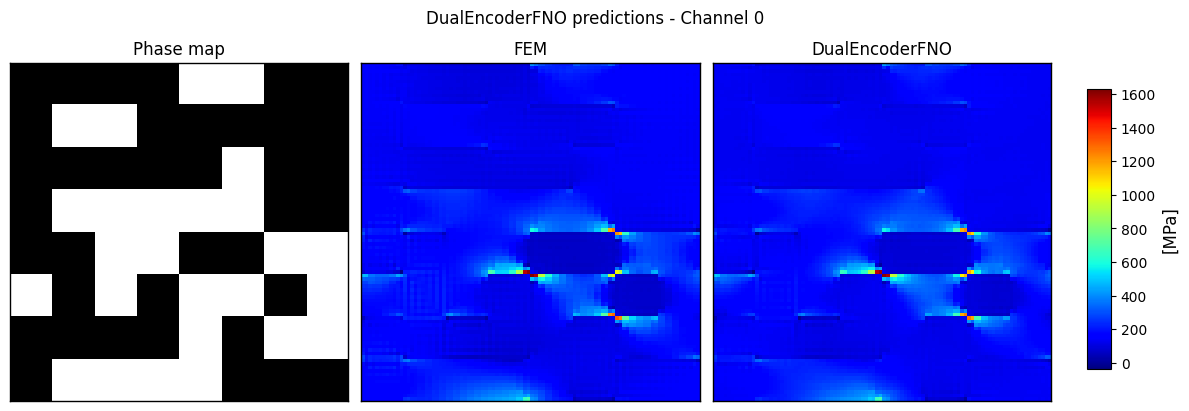

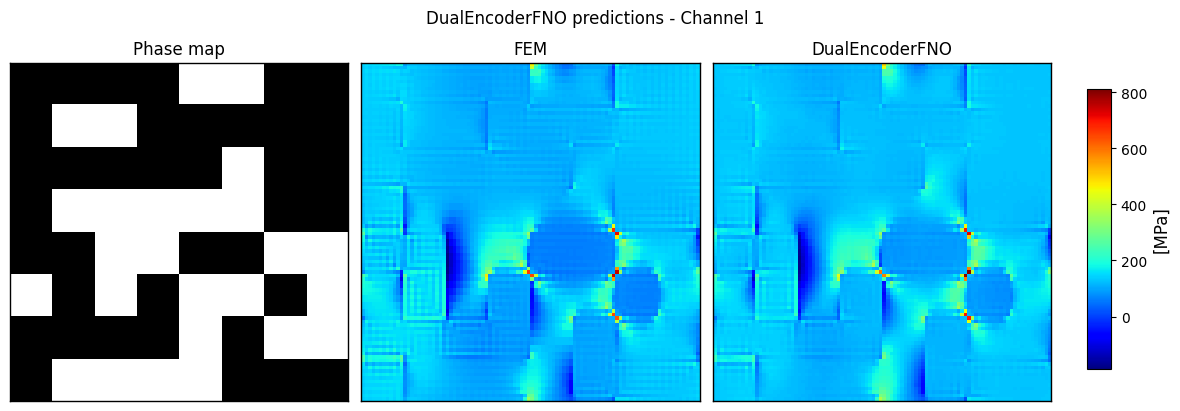

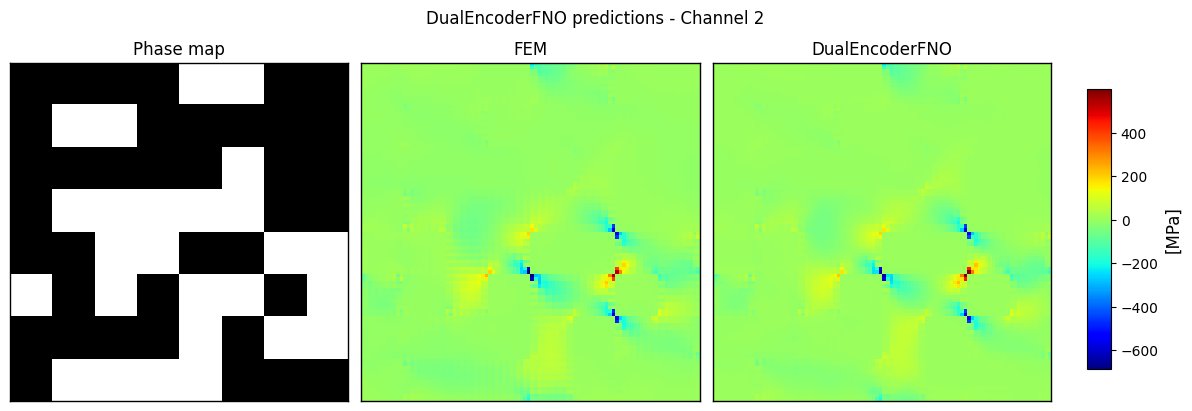

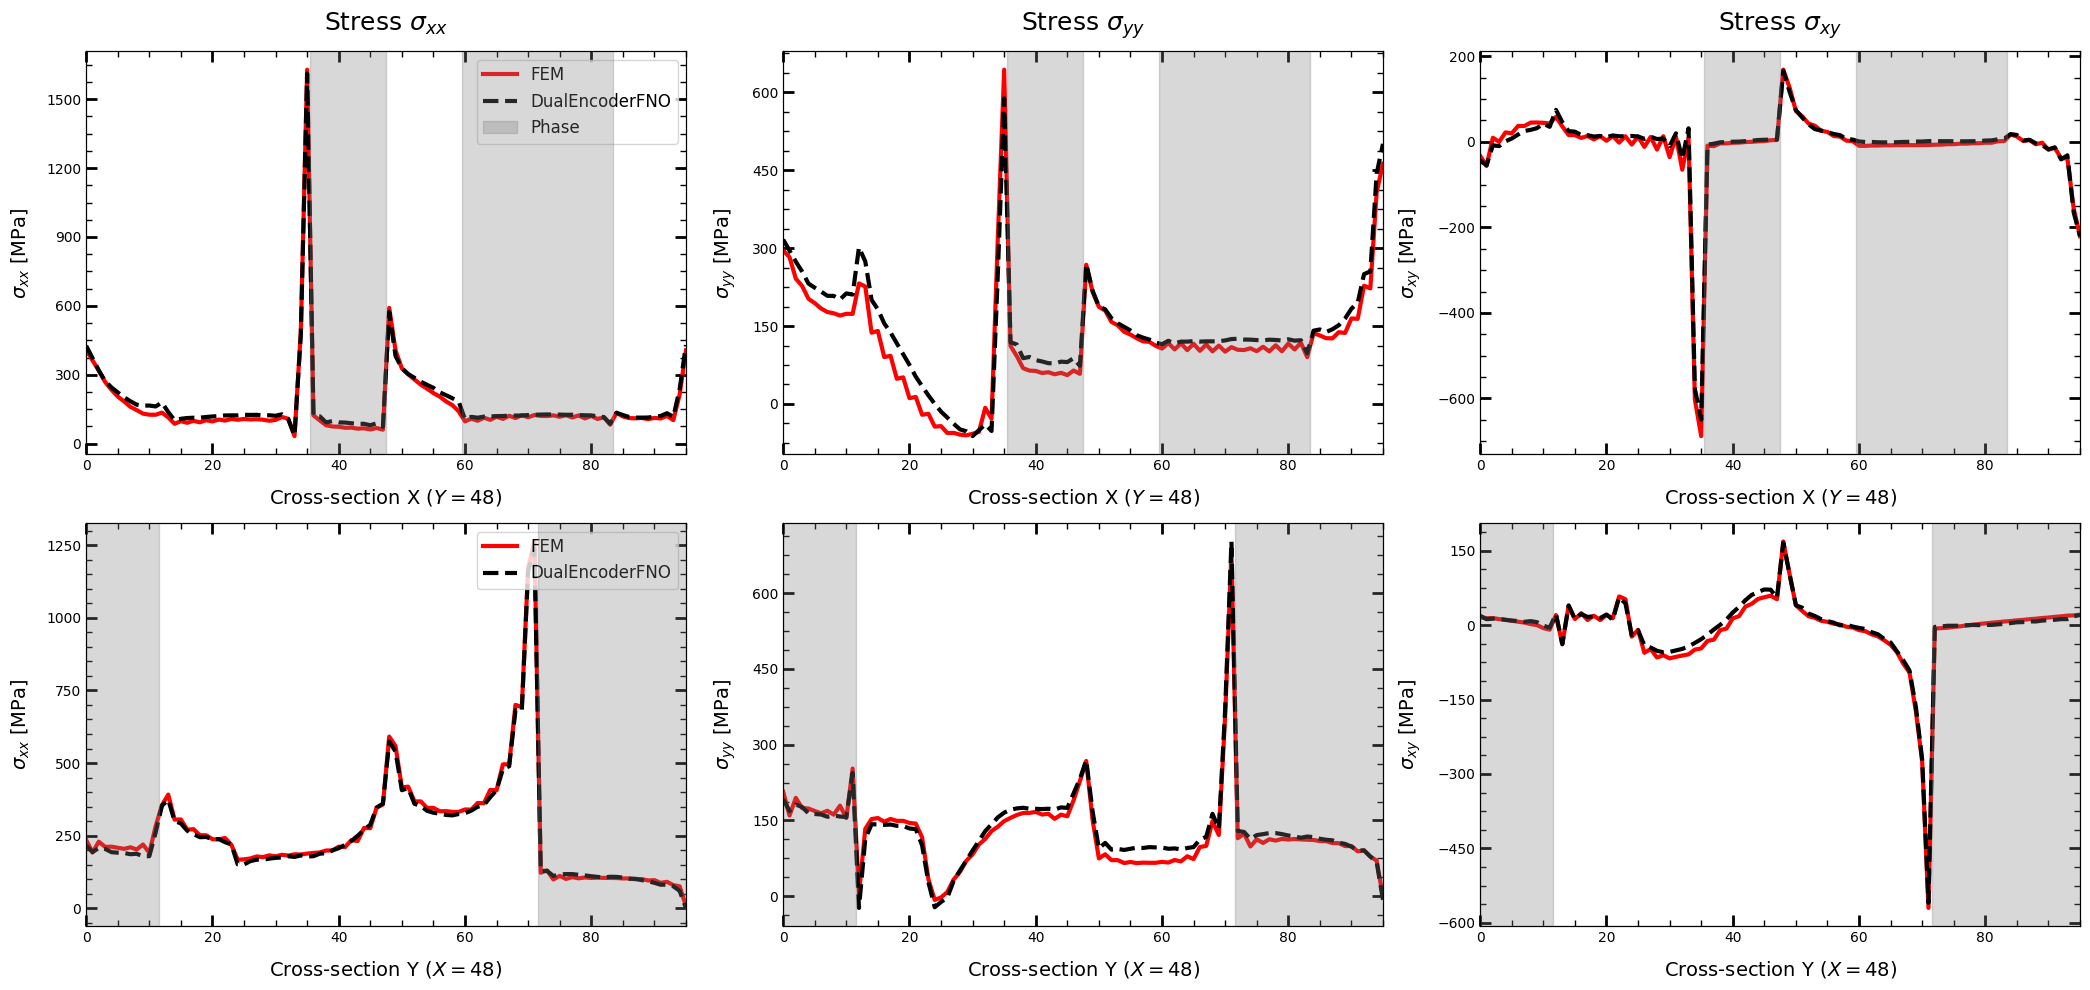

Sample 19297:


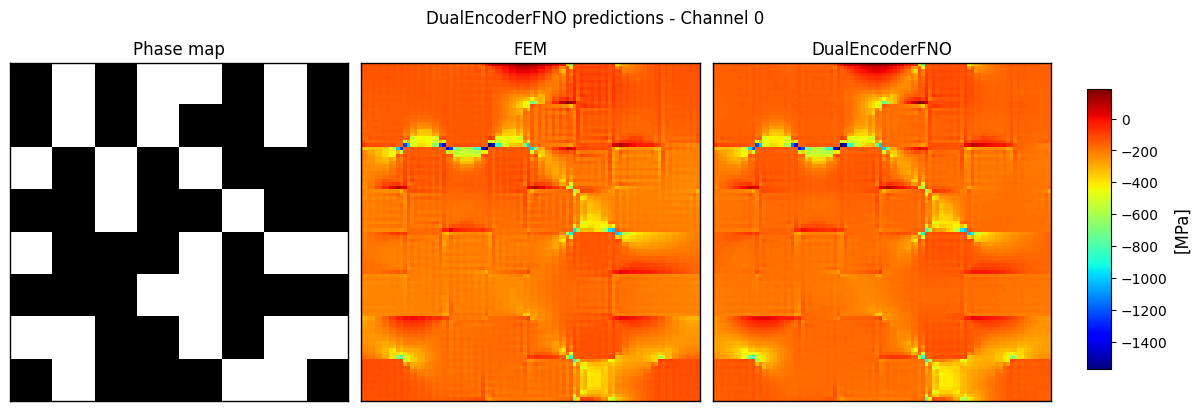

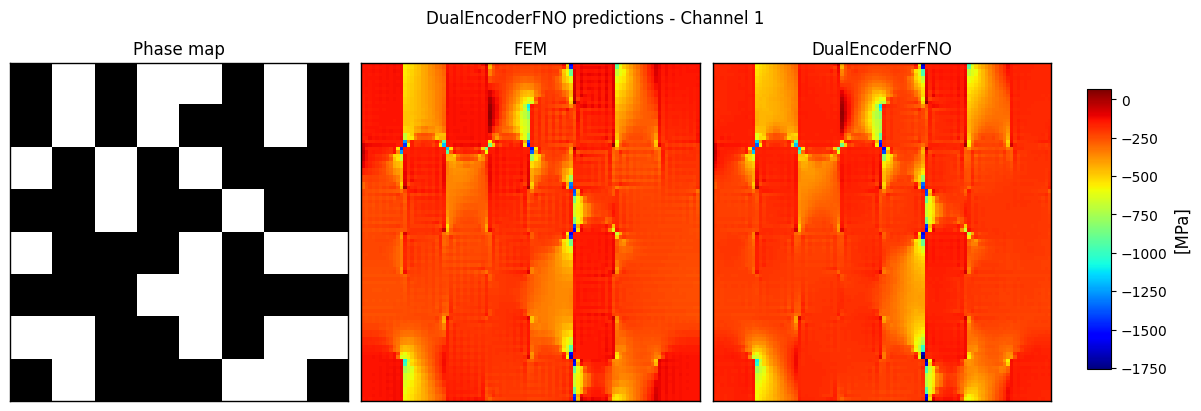

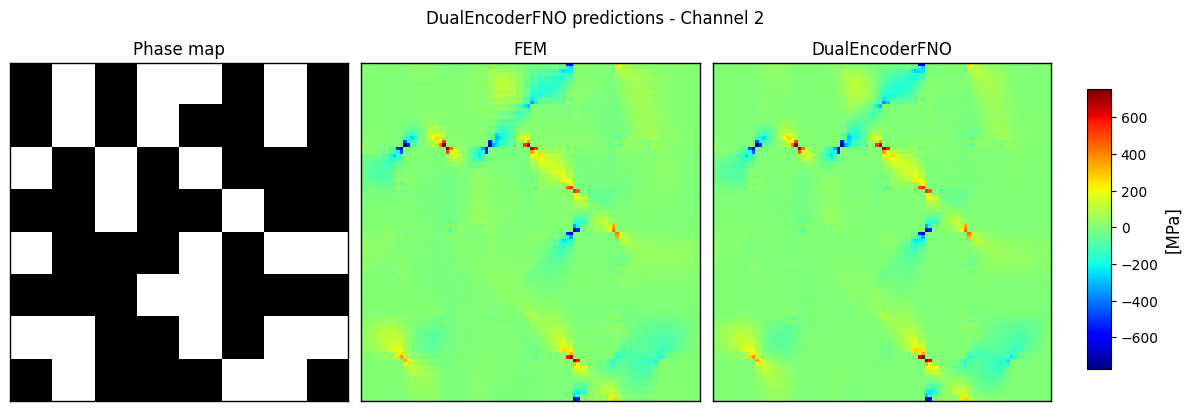

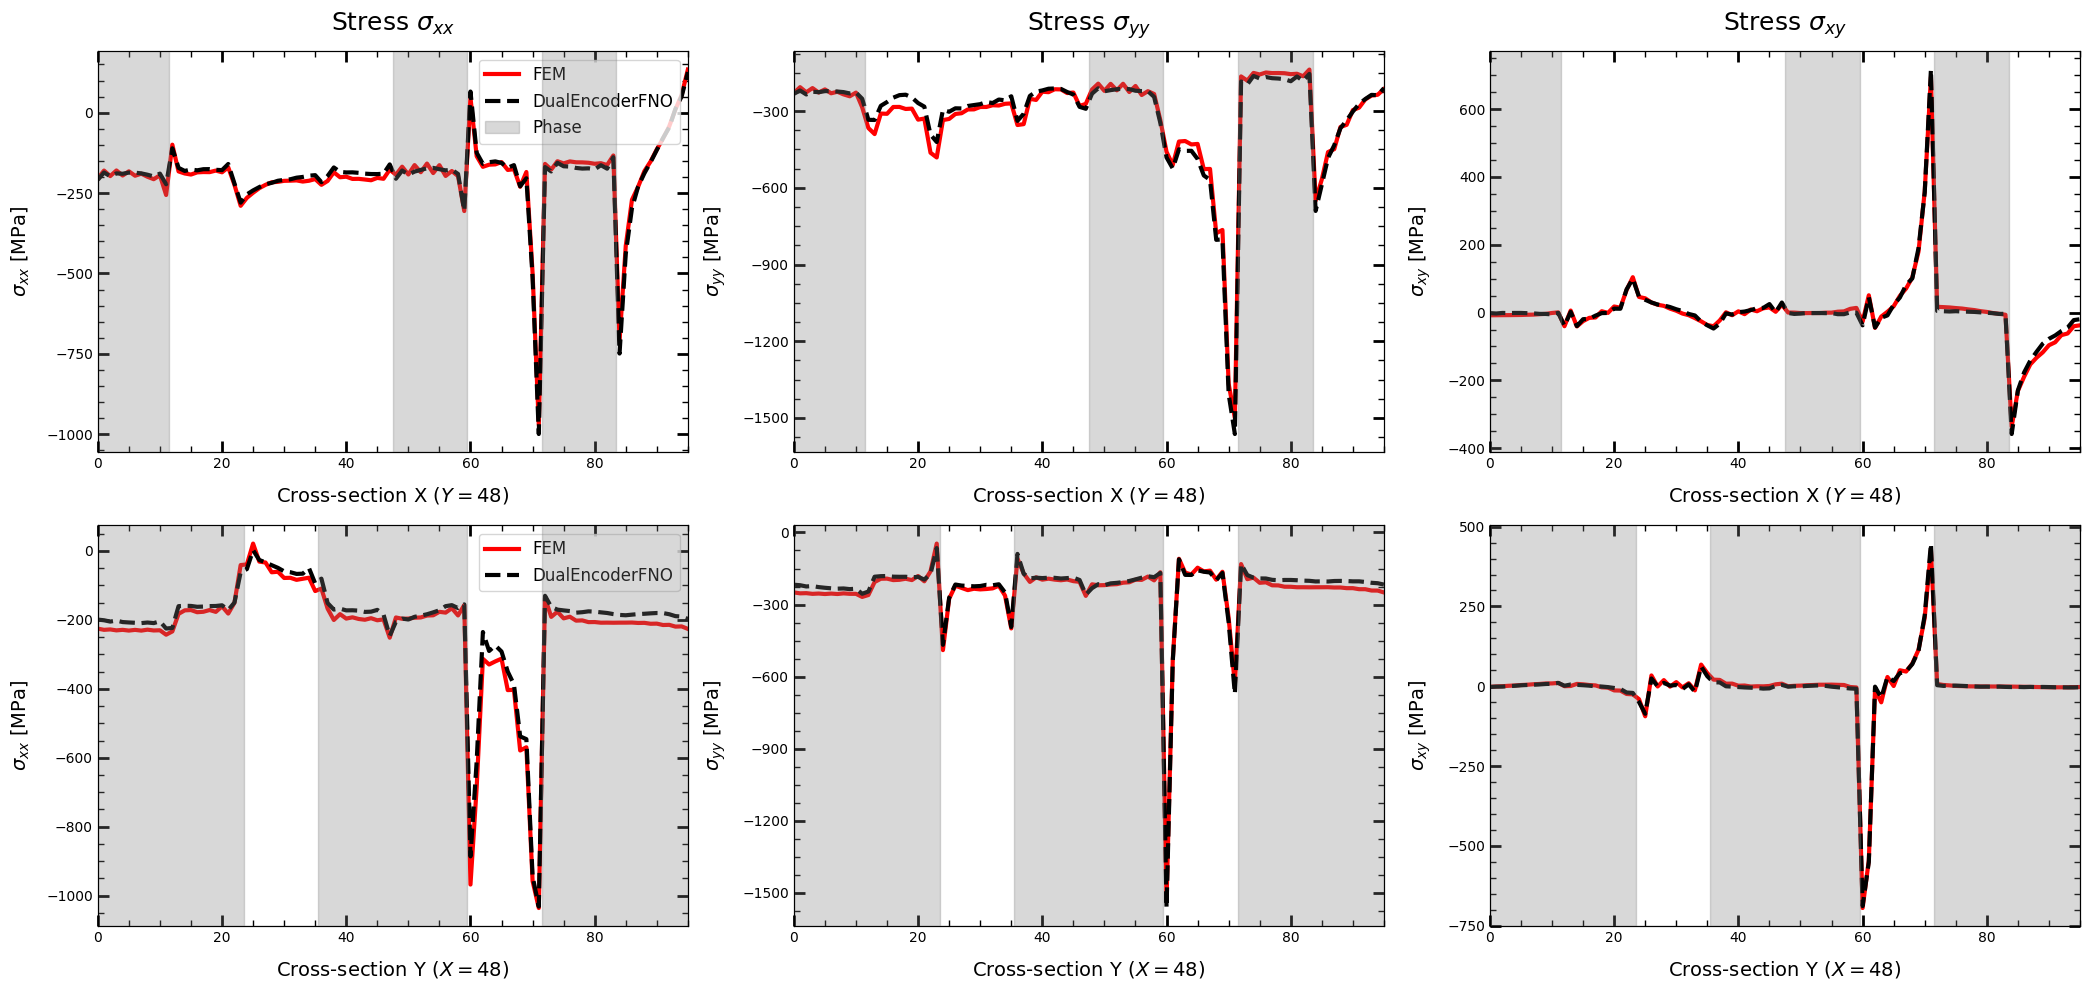

Sample 3700:


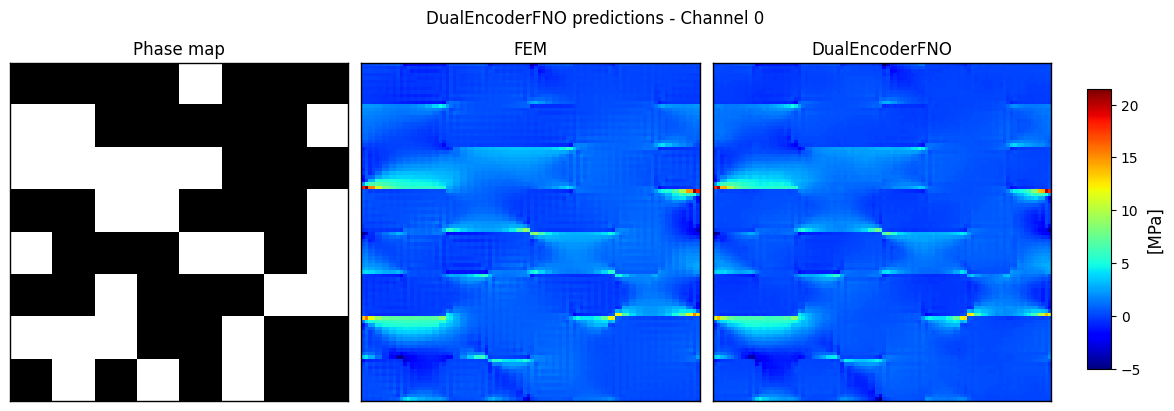

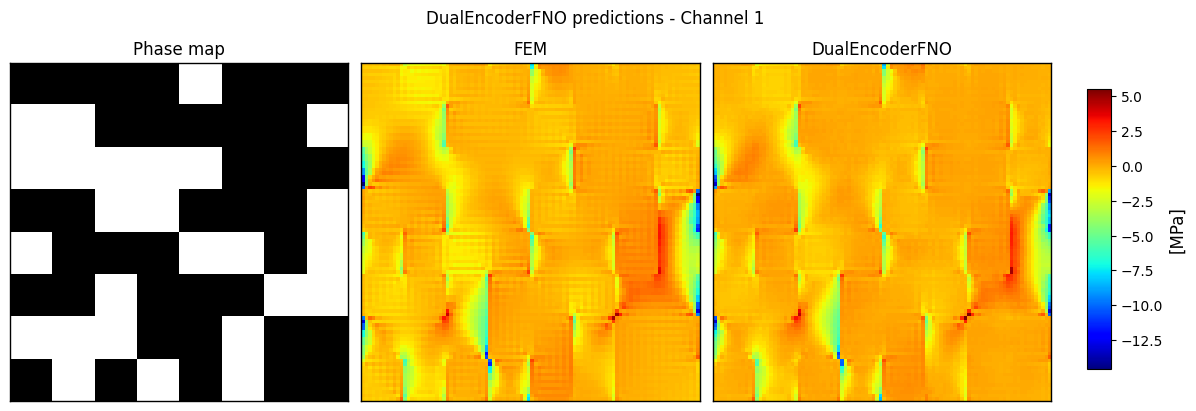

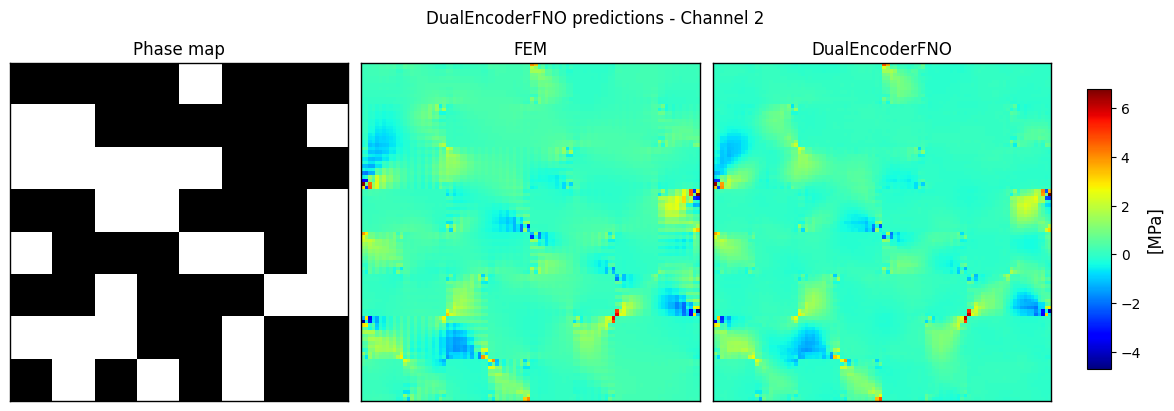

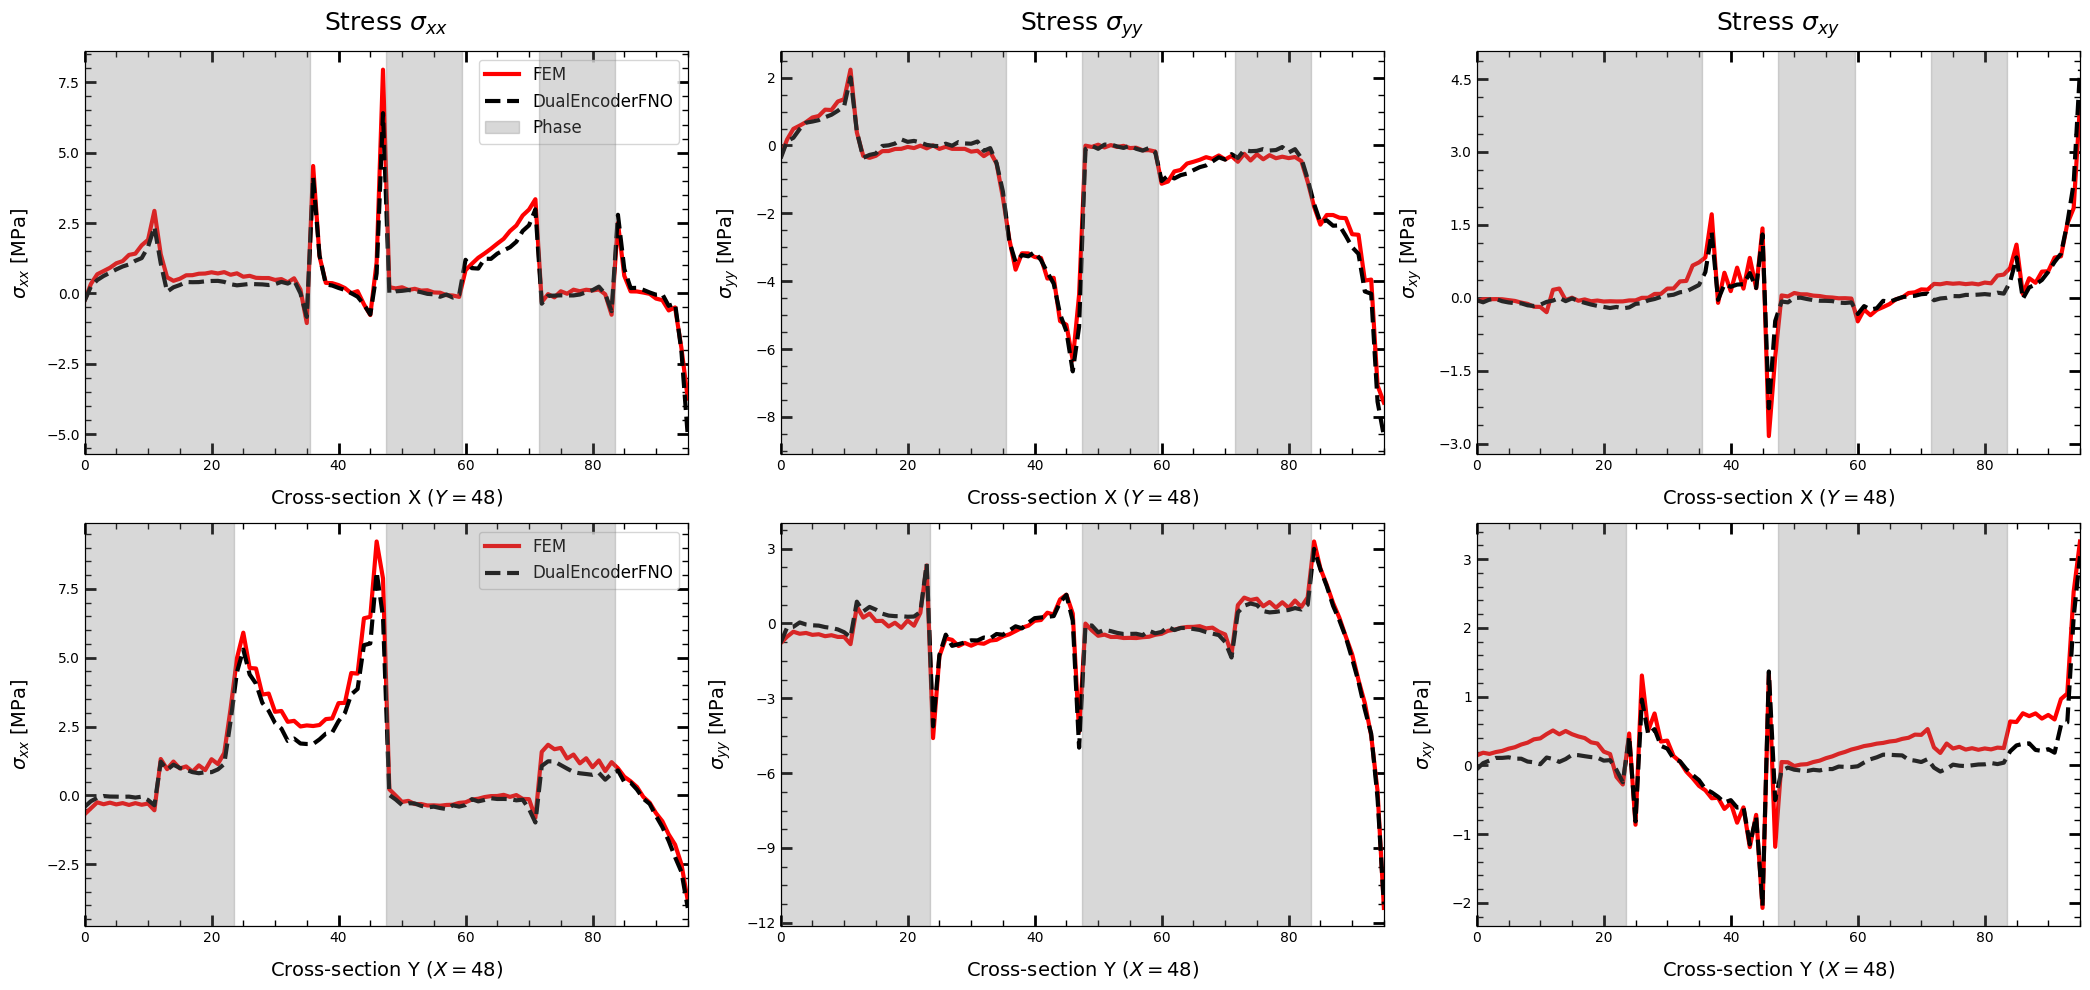

In [17]:
import random

# Visualize more samples
total_samples = y_true.shape[0] 
idxs = random.sample(range(total_samples), 5)

for idx in idxs:
    print(f"Sample {idx}:")
    
    for ch_i in range(3):
        RVEVisualizer.plot_contours(
        phase=phase_array,  # Phase map
        y_true=y_true,      # Ground truth
        y_pred=y_pred,      # Prediction
        index=idx,           # Case to visualize
        channel=ch_i,          # Channel to visualize
        cmap='jet'          # 
        )
        
    RVEVisualizer.plot_cross_sections(phase_array, y_true, y_pred, index=idx, variable='Stress')

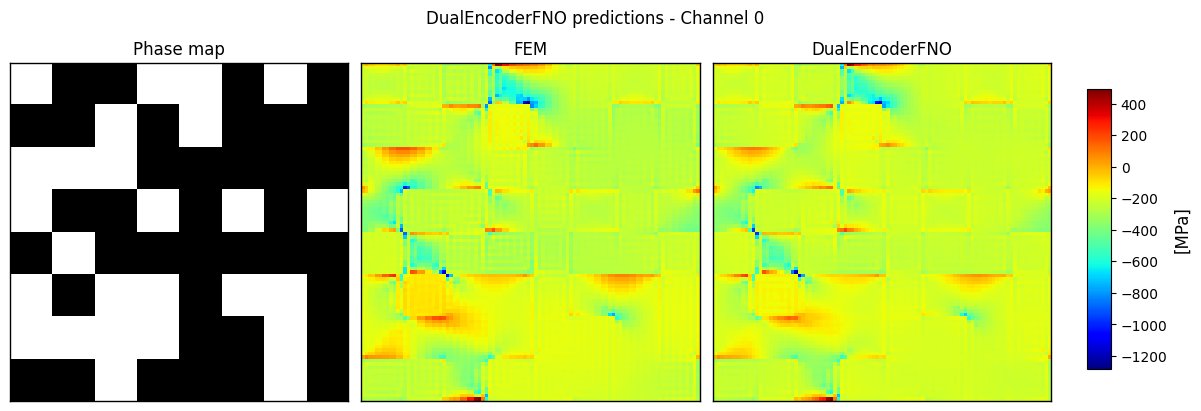

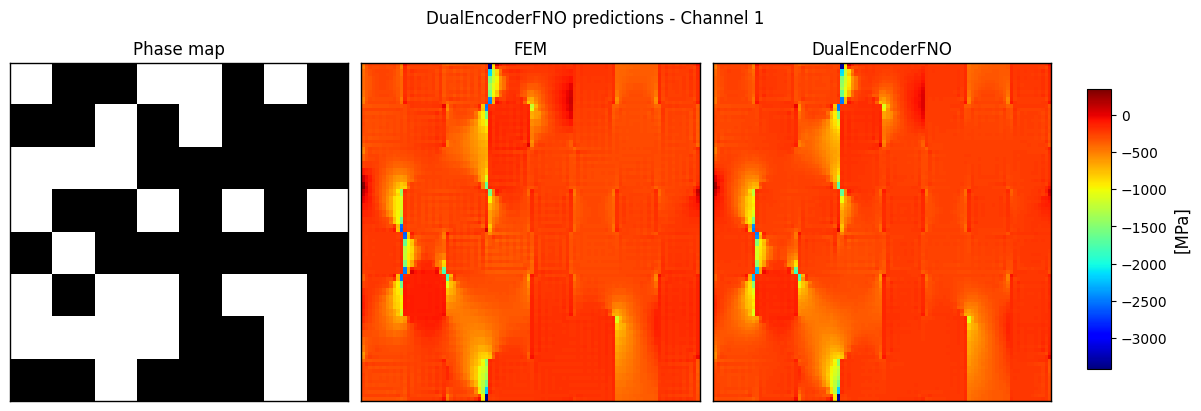

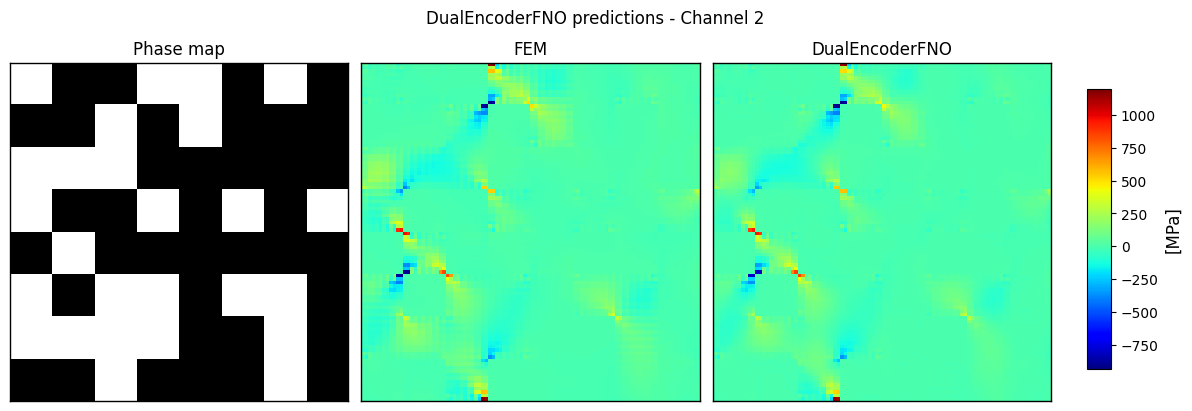

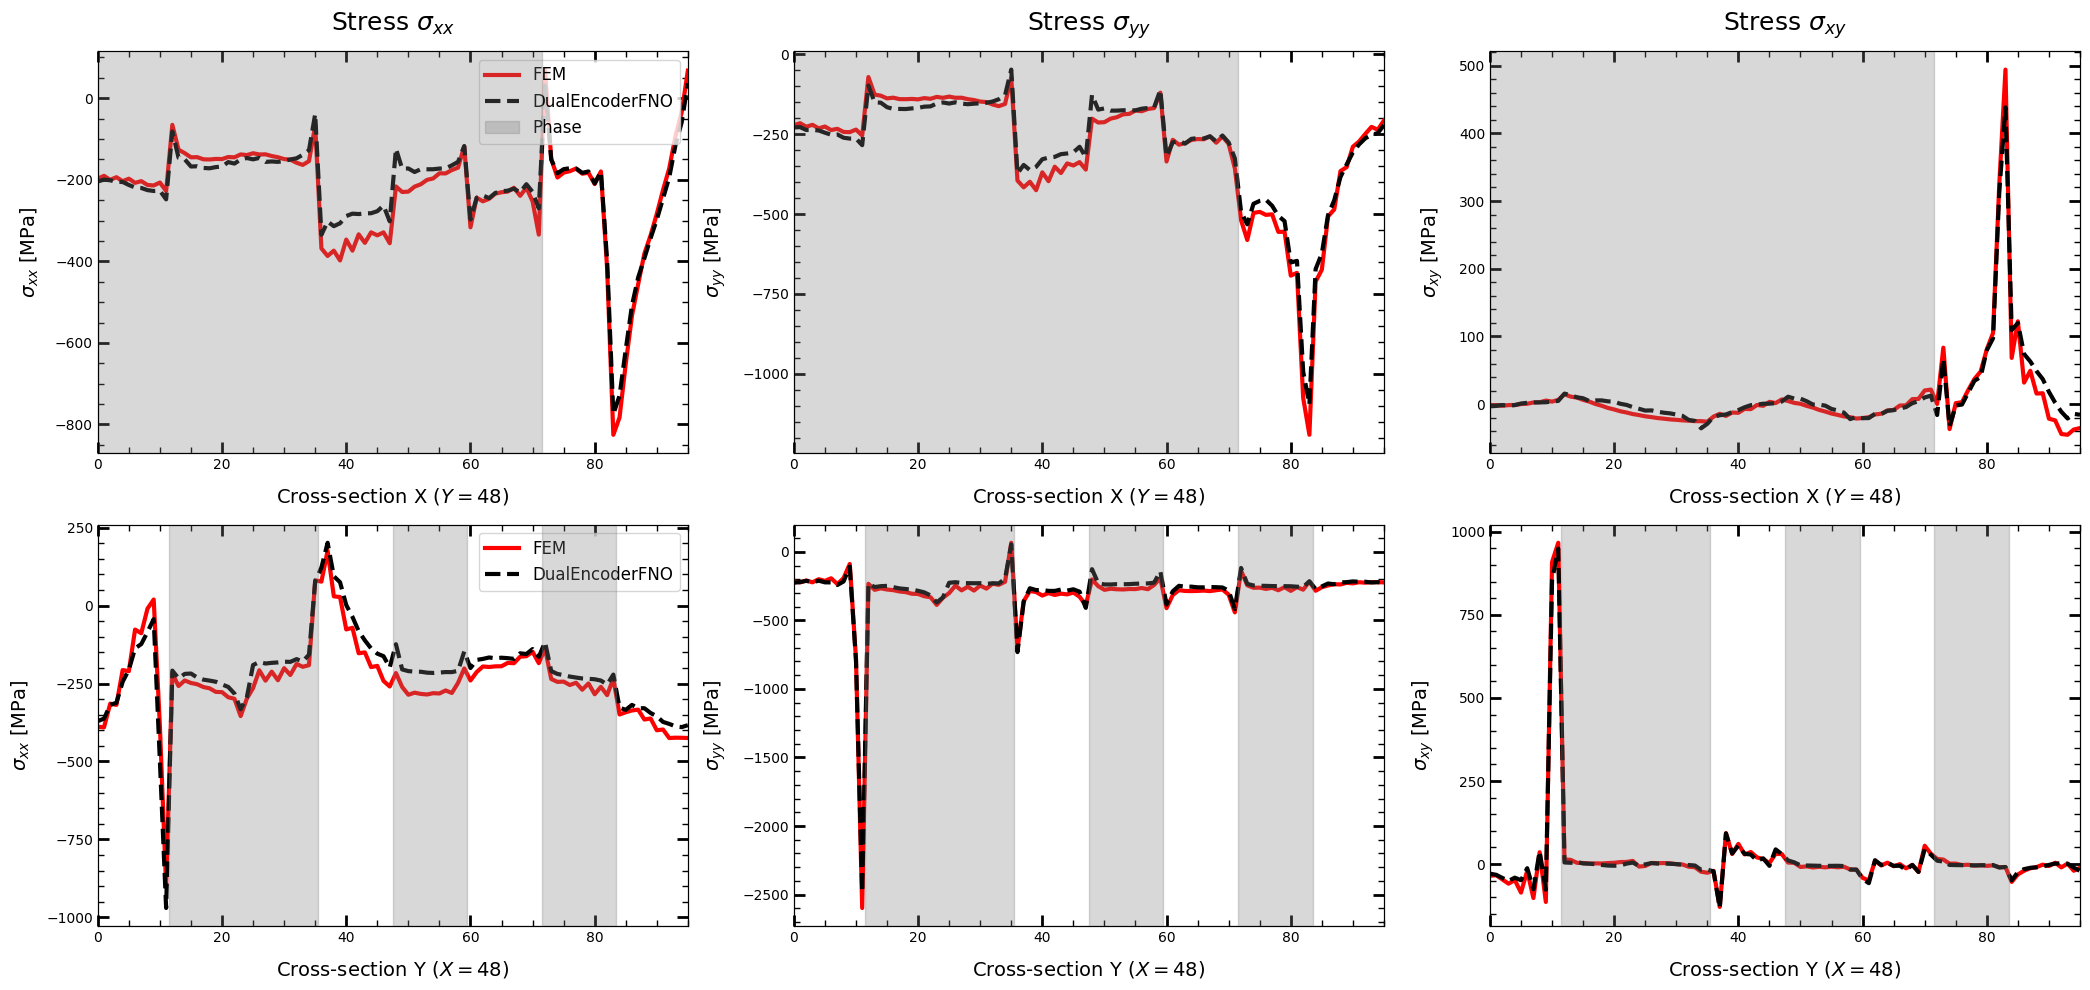

In [18]:
for ch_i in range(3):
    RVEVisualizer.plot_contours(
    phase=phase_array,  # Phase map
    y_true=y_true,      # Ground truth
    y_pred=y_pred,      # Prediction
    index=99,           # Case to visualize
    channel=ch_i,          # Channel to visualize
    cmap='jet'          # 
    )

RVEVisualizer.plot_cross_sections(phase_array, y_true, y_pred, index=99, variable='Stress')